In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

pd.set_option('display.float_format', '{:.2f}'.format)

# Getting data + first statistics

In [ ]:
df_train = pd.read_csv("data/training_set_VU_DM.csv", index_col=0)
df_train.head()

,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
srch_id,,,,,,,,,,,,,,,,,,,,,
1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,1,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [ ]:
print(f"Shape: {df_train.shape}")
print(f"Time range: {df_train['date_time'].min()} to {df_train['date_time'].max()}")

Shape: (4958347, 53)
Time range: 2012-11-01 00:08:29 to 2013-06-30 23:58:24


In [156]:
df_train.columns

Index(['date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate', 'comp7_in

In [5]:
df_train["date_time"] = pd.to_datetime(df_train["date_time"])

In [23]:
print("# of different site:", len(df_train['site_id'].unique()))
print("# of different site:", len(df_train['visitor_location_country_id'].unique()))
# print("# of users/ sereaches:", len(df_train['visitor_location_country_id'].unique()))
print("# of properties:", len(df_train['prop_id'].unique()))
print("# of search destinations:", len(df_train['srch_destination_id'].unique()))


# of different site: 34
# of different site: 210
# of properties: 129113
# of search destinations: 18127


In [ ]:
# Alleen numerieke kolommen (voorkomt errors)
num_df = df_train.select_dtypes(include='number')

# Basis statistieken
var_stats = num_df.agg(['count', 'mean', 'std', 'min', 'max']).T.round(3)

# % missing
nan_pct = (num_df.isna().mean() * 100).round(1)
var_stats['pct_nan'] = nan_pct

var_stats['pct_zero'] = (df_train == 0).mean() * 100

var_stats = var_stats.round(3)

# aantal unieke waarden
nunique = num_df.nunique()
var_stats['n_unique'] = nunique

In [164]:
# sorteren
var_stats.sort_values(by='pct_zero', ascending=False)

,count,mean,std,min,max,pct_nan,pct_zero,n_unique
booking_bool,4958347.00,0.03,0.17,0.00,1.00,0.00,97.21,2
click_bool,4958347.00,0.04,0.21,0.00,1.00,0.00,95.53,2
promotion_flag,4958347.00,0.22,0.41,0.00,1.00,0.00,78.44,2
srch_children_count,4958347.00,0.35,0.73,0.00,9.00,0.00,76.88,10
random_bool,4958347.00,0.30,0.46,0.00,1.00,0.00,70.41,2
srch_saturday_night_bool,4958347.00,0.50,0.50,0.00,1.00,0.00,49.78,2
comp5_inv,2360020.00,0.05,0.27,-1.00,1.00,52.40,44.06,3
comp2_inv,2130269.00,0.04,0.23,-1.00,1.00,57.00,40.54,3
comp8_inv,1987503.00,0.01,0.20,-1.00,1.00,59.90,38.43,3
prop_brand_bool,4958347.00,0.64,0.48,0.00,1.00,0.00,36.53,2


# distributions

In [126]:
cols_2 = var_stats[var_stats['n_unique'] == 2].index
cols_3 = var_stats[var_stats['n_unique'] == 3].index
cols_10 = var_stats[(var_stats['n_unique'] >= 4) & (var_stats['n_unique'] <= 40)].index
cols_rest = var_stats[(var_stats['n_unique'] >= 41) ].index


def make_wide_counts_pct(df, cols):
    rows = []

    for col in cols:
        counts = df[col].value_counts(dropna=False)
        pct = (
            df[col].value_counts(normalize=True, dropna=False).mul(100).round(2))

        row = {'column': col}

        for val in counts.index:
            row[f'{val}_count'] = counts[val] 
            row[f'{val}_pct'] = pct[val]


        rows.append(row)

    return pd.DataFrame(rows).fillna(0)
table_2 = make_wide_counts_pct(df_train, cols_2)
table_3 = make_wide_counts_pct(df_train, cols_3)

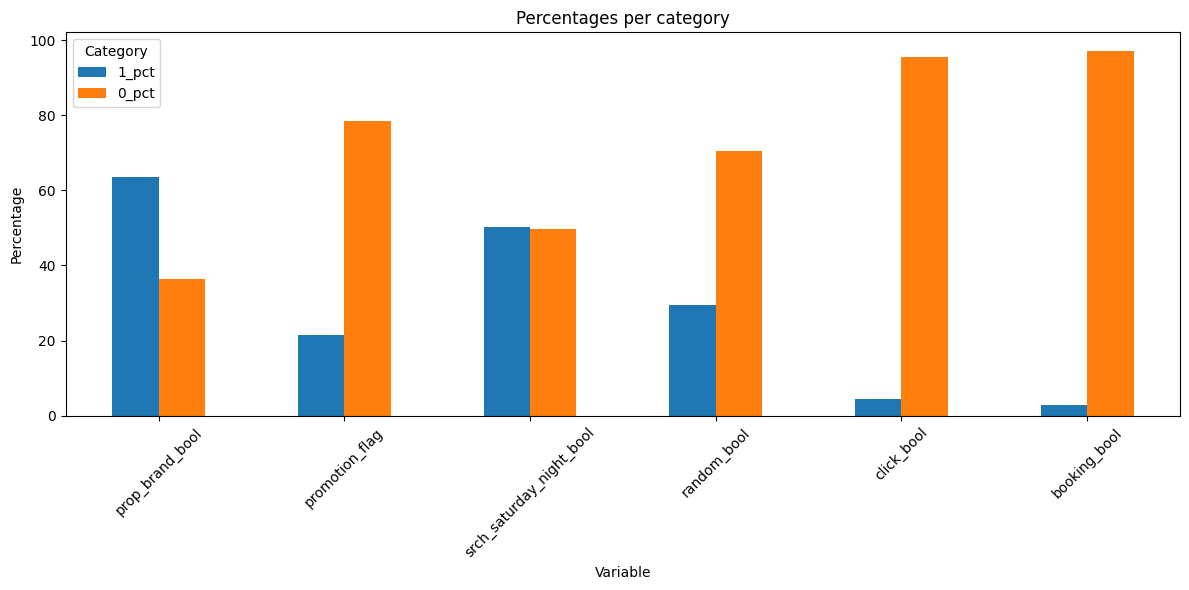

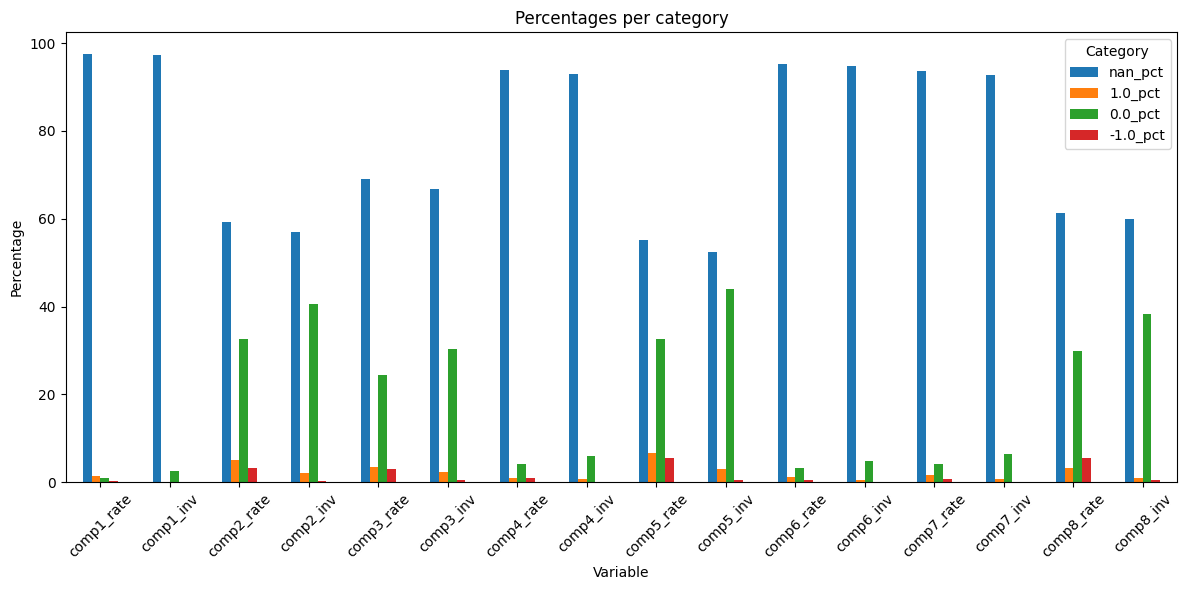

In [ ]:
# bar plot for features with 2 or 3 unique values
for wide in [ table_2, table_3]:
    # alleen percentage kolommen
    pct_cols = [c for c in wide.columns if '_pct' in c]

    # dataframe voor plot
    plot_df = wide[['column'] + pct_cols]

    import matplotlib.pyplot as plt

    plot_df.set_index('column').plot(
        kind='bar',
        figsize=(12,6)
    )

    plt.ylabel('Percentage')
    plt.xlabel('Variable')
    plt.title('Percentages per category')
    plt.legend(title='Category')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

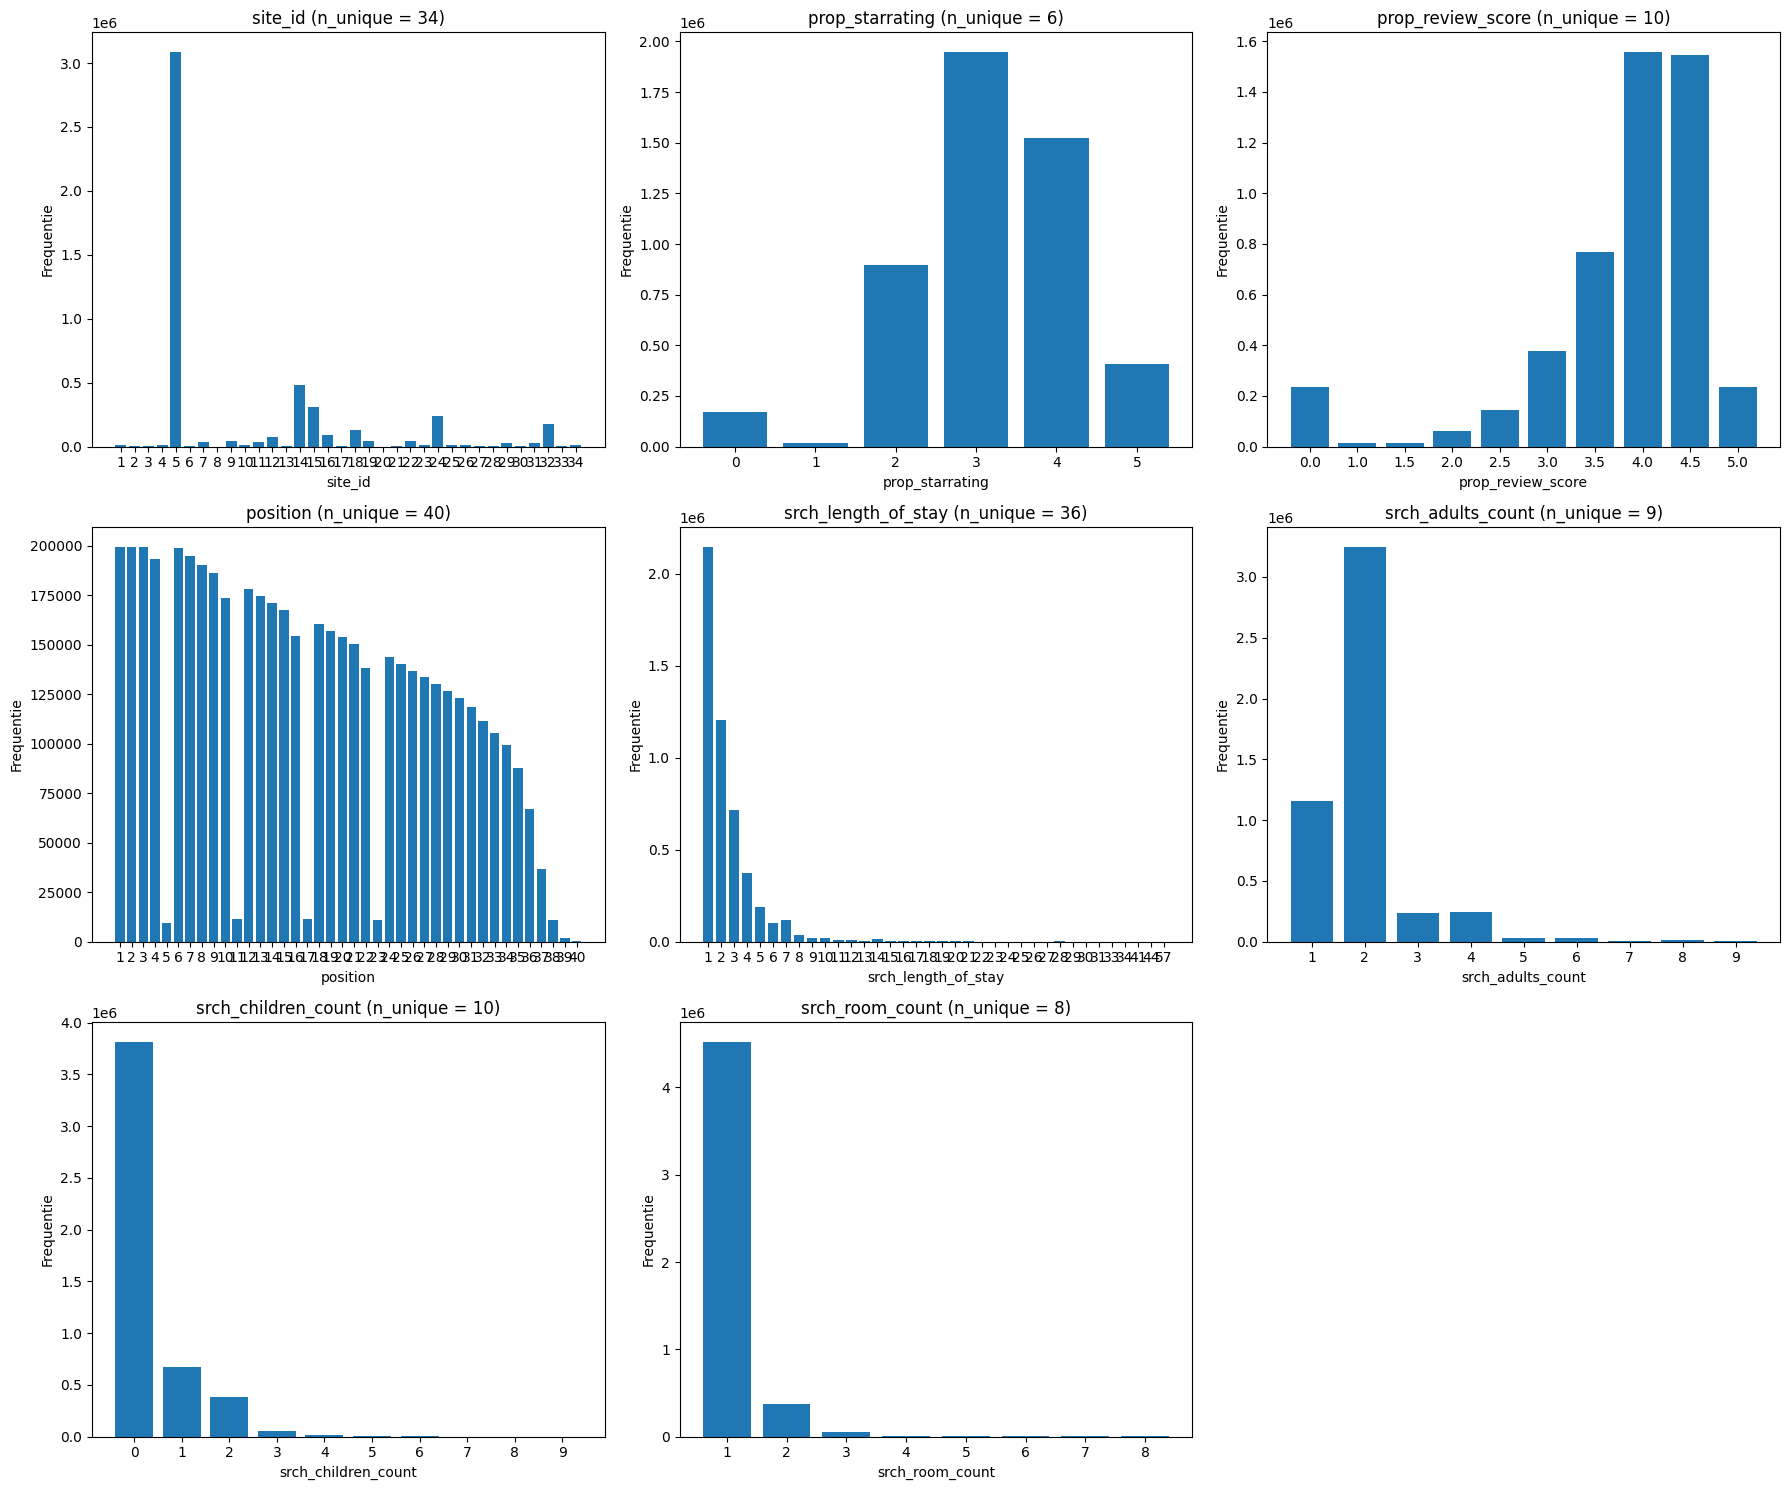

In [ ]:
# bar plot for features with 4 until 40 unique values
n_cols = 3
n_rows = math.ceil(len(cols_10) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_10):

    counts = df_train[col].value_counts().sort_index()

    axes[i].bar(counts.index.astype(str), counts.values)

    axes[i].set_title(
        f"{col} (n_unique = {var_stats.loc[col, 'n_unique']})"
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequentie")

# lege subplots verwijderen
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

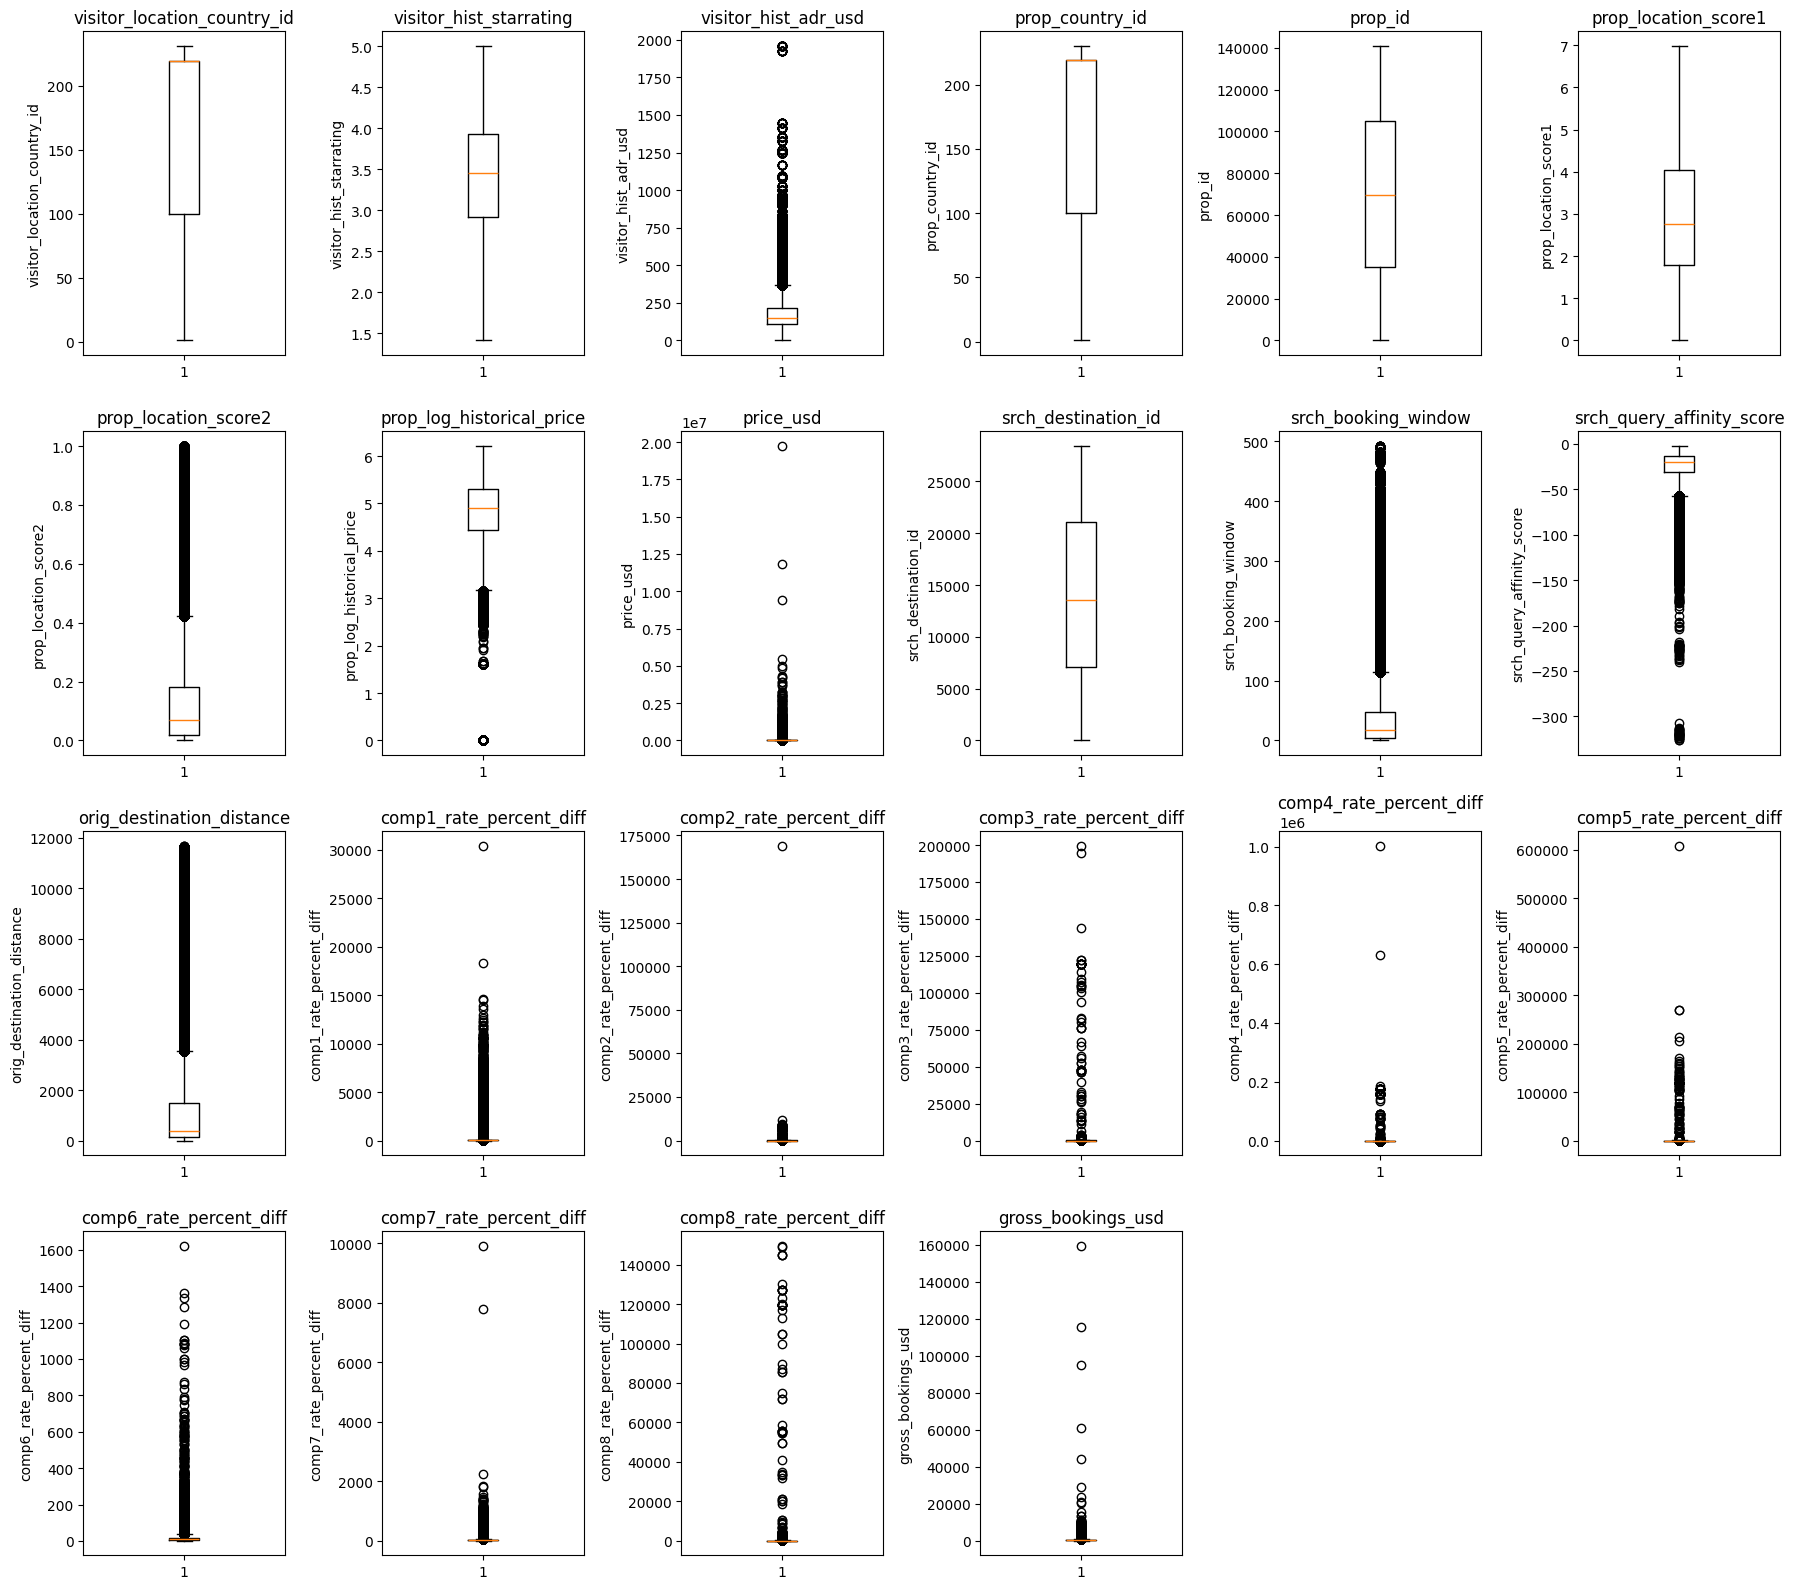

In [ ]:
#Boxplot of features with more than 40 unique values
n_cols = 6
n_rows = math.ceil(len(cols_rest) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_rest):

    axes[i].boxplot(df_train[col].dropna(), vert=True)

    axes[i].set_title(f"{col}")
    axes[i].set_ylabel(col)

# lege assen verwijderen
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# skewness factors
df_train[cols_rest].skew().sort_values()

srch_query_affinity_score      -2.50
prop_log_historical_price      -1.74
prop_country_id                -1.07
visitor_location_country_id    -1.05
visitor_hist_starrating        -0.07
prop_id                         0.01
srch_destination_id             0.08
prop_location_score1            0.12
prop_location_score2            1.93
orig_destination_distance       2.39
srch_booking_window             2.41
visitor_hist_adr_usd            3.40
comp1_rate_percent_diff         5.35
comp6_rate_percent_diff        16.12
comp4_rate_percent_diff        69.07
comp7_rate_percent_diff        72.18
gross_bookings_usd             89.41
comp3_rate_percent_diff       118.21
comp8_rate_percent_diff       130.06
comp5_rate_percent_diff       194.37
price_usd                     588.94
comp2_rate_percent_diff       628.39
dtype: float64

price_usd: 49329 waarden verwijderd (>599.00) | 0.99% van data
comp1_rate_percent_diff: 931 waarden verwijderd (>6534.00) | 0.99% van data
comp2_rate_percent_diff: 5341 waarden verwijderd (>100.00) | 0.96% van data
comp3_rate_percent_diff: 4714 waarden verwijderd (>99.00) | 1.00% van data
comp4_rate_percent_diff: 1301 waarden verwijderd (>122.00) | 0.99% van data
comp5_rate_percent_diff: 7460 waarden verwijderd (>98.00) | 0.89% van data
comp7_rate_percent_diff: 1373 waarden verwijderd (>123.00) | 0.99% van data
gross_bookings_usd: 1384 waarden verwijderd (>2553.15) | 1.00% van data


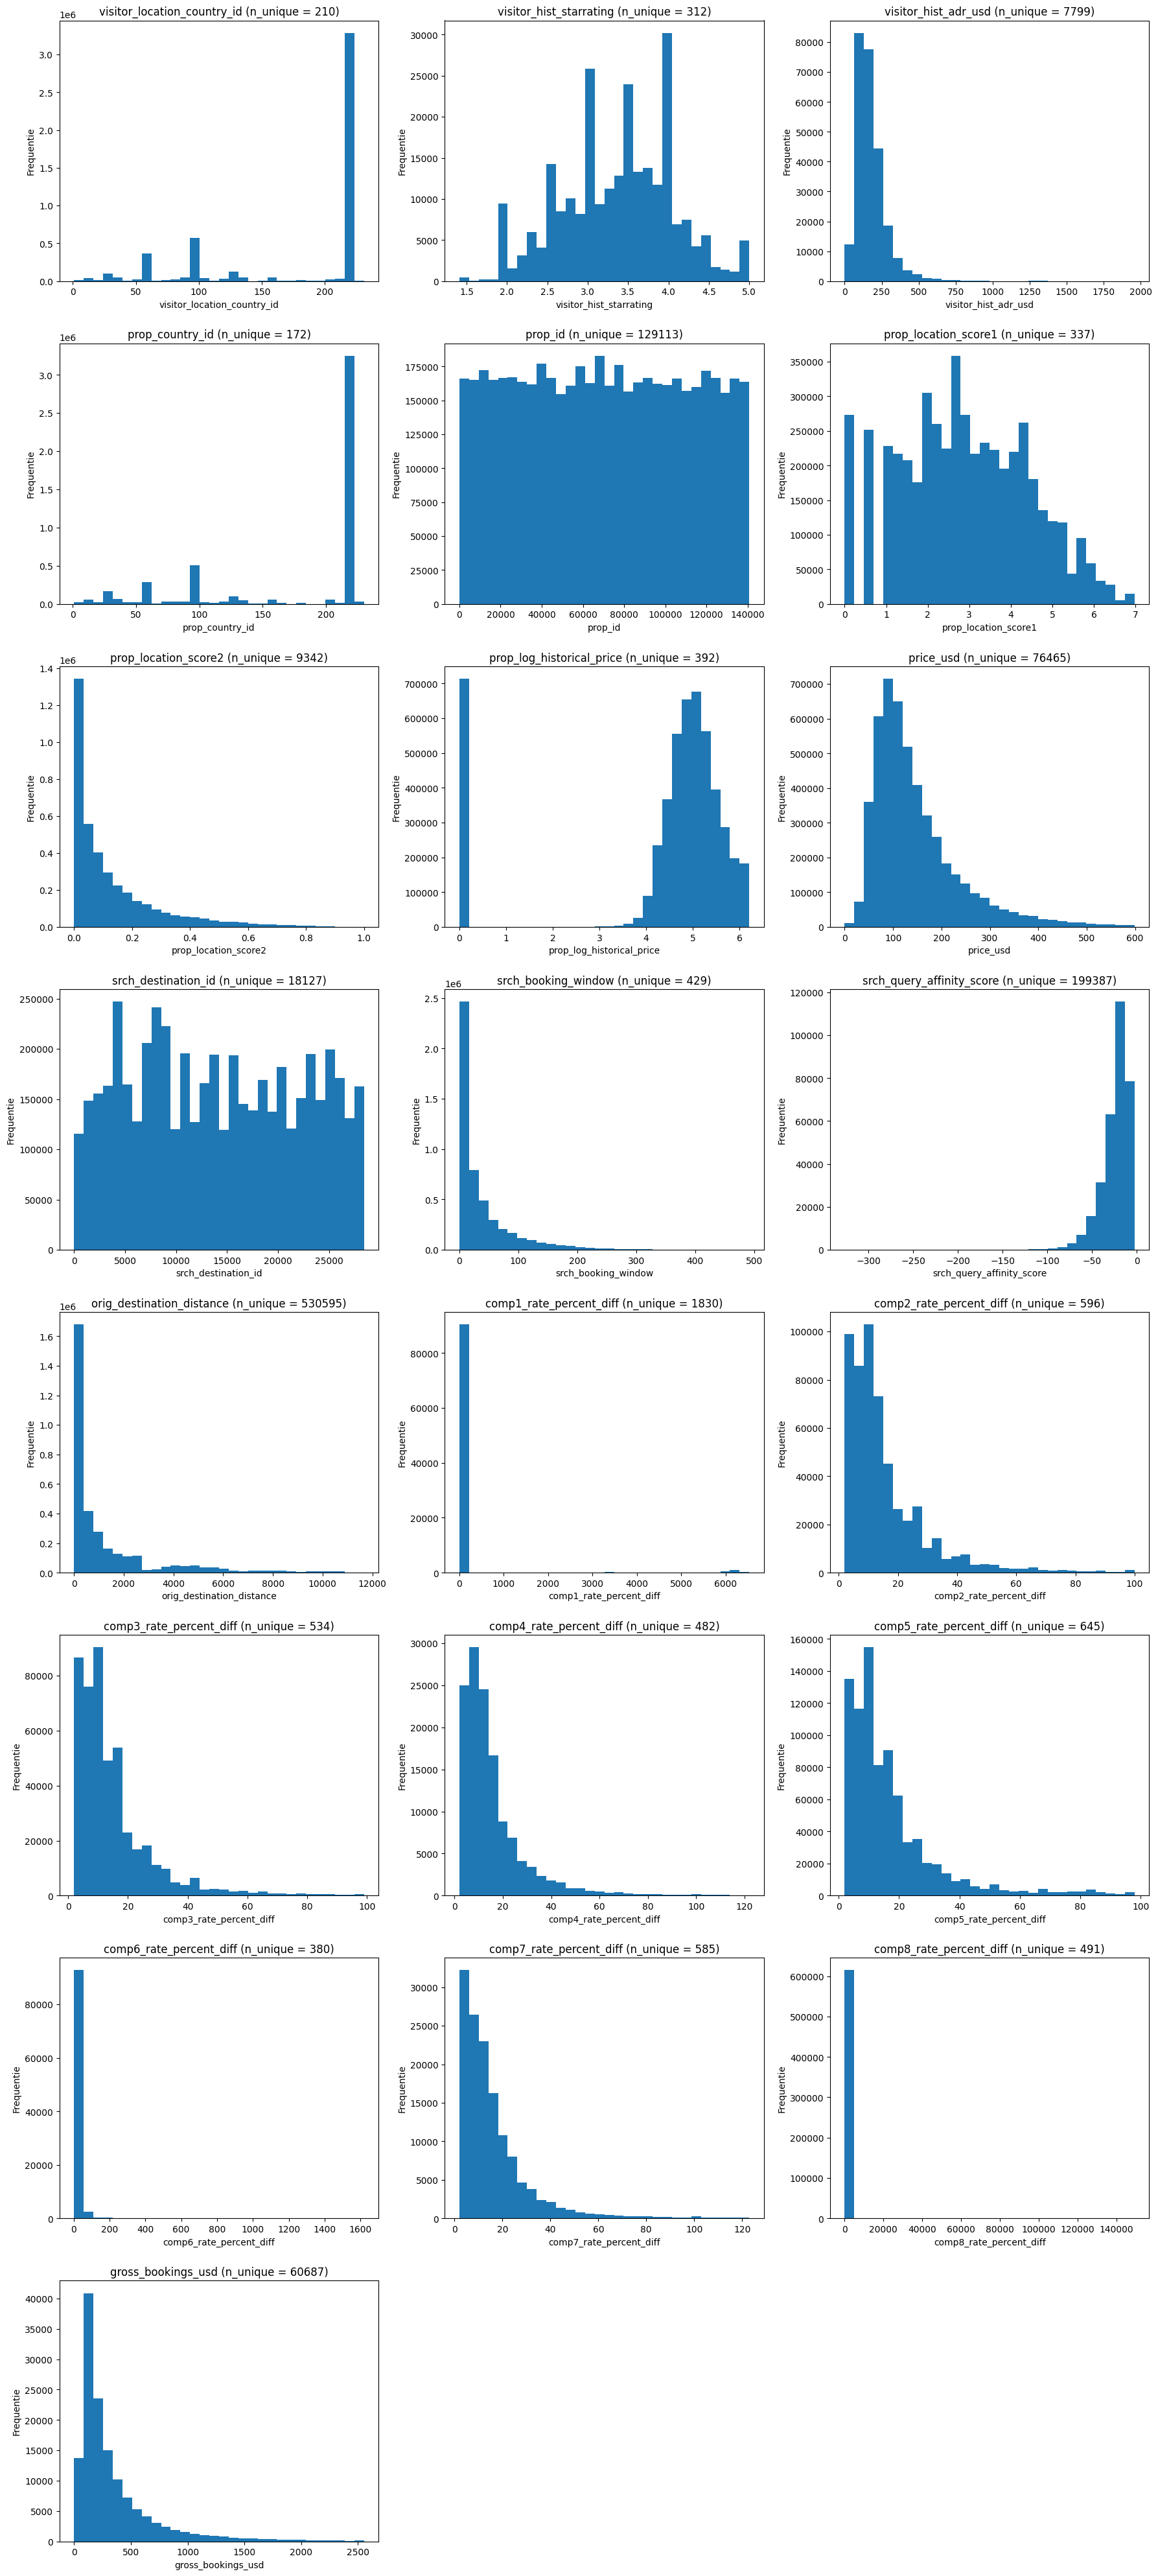

In [ ]:
# Histograms of features with at least 40 unique values
# if at leas 30% of the bins are emty --> delete top 1 %

n_cols = 3
n_rows = math.ceil(len(cols_rest) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_rest):

    s_original = df_train[col].dropna()

    # check histogram bins
    counts, bins = np.histogram(s_original, bins=30)

    empty_ratio = (counts == 0).mean()

    s = s_original.copy()

    # outliers verwijderen indien nodig
    if empty_ratio > 0.3:

        upper = s.quantile(0.99)

        before = len(s)

        s = s[s <= upper]

        removed = before - len(s)

        print(
            f"{col}: {removed} waarden verwijderd "
            f"(>{upper:.2f}) | "
            f"{removed/before:.2%} van data"
        )

    axes[i].hist(s, bins=30)

    axes[i].set_title(
        f"{col} (n_unique = {var_stats.loc[col, 'n_unique']})"
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequentie")

# lege subplotten verwijderen
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Correlation

### with booking_bool and click_bool

In [ ]:
# with booksings

num_df = df_train.select_dtypes(include='number')

# drop slechte kolommen
num_df = num_df.drop(columns=['prop_id', 'position', 'gross_bookings_usd'], errors='ignore')

# correlatie met booking
corr_booking = num_df.corr()['booking_bool'].sort_values(ascending=False)

corr_booking.head(15)

booking_bool                1.00
click_bool                  0.78
prop_location_score2        0.07
promotion_flag              0.04
prop_review_score           0.03
srch_query_affinity_score   0.03
comp8_rate                  0.02
prop_starrating             0.02
comp5_rate                  0.02
comp4_rate                  0.02
comp3_rate                  0.02
comp2_rate                  0.02
comp6_rate                  0.01
comp7_rate                  0.01
comp1_rate                  0.01
Name: booking_bool, dtype: float64

In [ ]:
# correlatie met click
corr_click = num_df.corr()['click_bool'].sort_values(ascending=False)
corr_click.head(15)

click_bool                  1.00
booking_bool                0.78
prop_location_score2        0.07
srch_query_affinity_score   0.04
promotion_flag              0.04
prop_starrating             0.03
comp8_rate                  0.02
prop_review_score           0.02
comp5_rate                  0.02
comp4_rate                  0.02
comp2_rate                  0.02
comp3_rate                  0.02
comp7_rate                  0.01
comp6_rate                  0.01
site_id                     0.01
Name: click_bool, dtype: float64

### highly correlated pairs

In [141]:
num_df = df_train.select_dtypes(include='number')
corr_matrix = num_df.corr()

In [157]:
high_corr = (
    corr_matrix
    # .abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr= high_corr.dropna()
high_corr = high_corr.reset_index()
high_corr.columns = ['feature_1', 'feature_2', 'correlation']
high_corr.head(10)

,feature_1,feature_2,correlation
0,click_bool,booking_bool,0.78
1,comp5_rate,comp8_rate,0.64
2,comp3_rate_percent_diff,comp8_rate_percent_diff,0.63
3,comp3_rate_percent_diff,comp5_rate_percent_diff,0.59
4,comp1_inv,comp5_inv,0.51
5,comp4_rate,comp8_rate,0.51
6,comp2_rate,comp3_rate,0.51
7,comp6_rate,comp7_rate,0.51
8,comp5_rate_percent_diff,comp8_rate_percent_diff,0.51
9,visitor_hist_starrating,visitor_hist_adr_usd,0.50


In [159]:
high_corr.tail(7)

,feature_1,feature_2,correlation
1317,prop_brand_bool,orig_destination_distance,-0.21
1318,visitor_location_country_id,visitor_hist_starrating,-0.26
1319,visitor_hist_starrating,prop_country_id,-0.29
1320,srch_length_of_stay,srch_saturday_night_bool,-0.29
1321,site_id,visitor_location_country_id,-0.31
1322,site_id,prop_country_id,-0.31
1323,prop_country_id,orig_destination_distance,-0.37


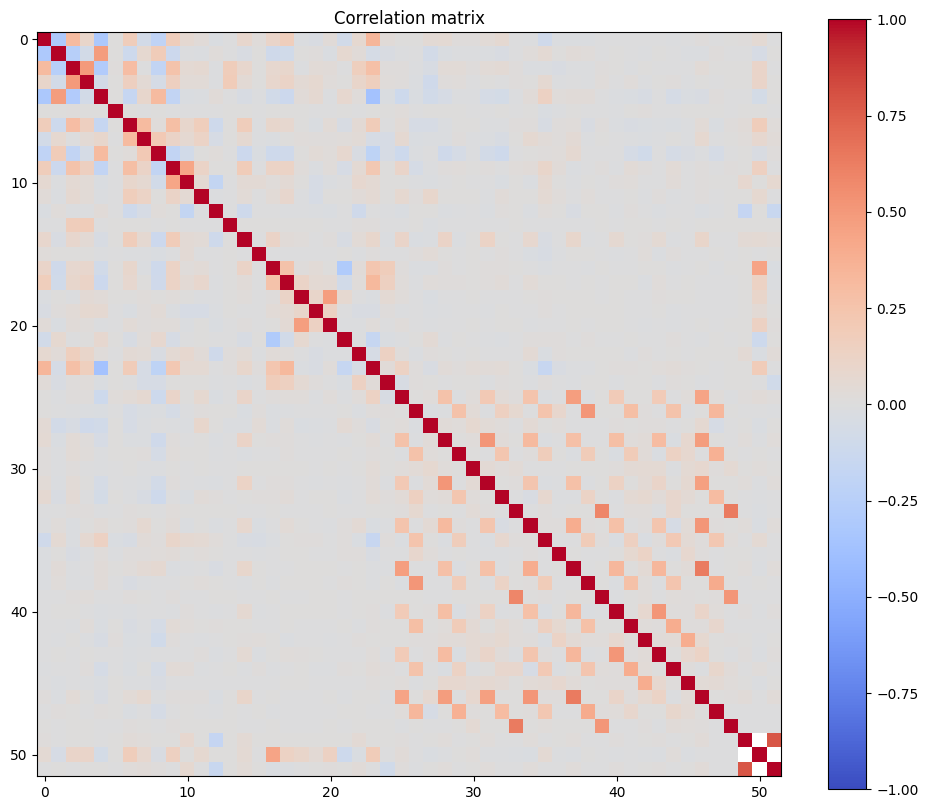

In [134]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(12,10))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Correlation matrix")
plt.show()

# Splitting into categories

In [33]:
ids = [i for i in df_train.columns if "id" in i]
stars = [i for i in df_train.columns if "star" in i]



visitor = [i for i in df_train.columns if "visitor" in i]
property = [i for i in df_train.columns if "prop" in i]
search =  [i for i in df_train.columns if "srch" in i]
comps = [i for i in df_train.columns if "comp" in i]
train_data_only = ['position', 'click_bool','booking_bool', 'gross_bookings_usd']
others = [i for i in df_train.columns if i not in visitor and i not in property and i not in search and i not in comps and i not in train_data_only ]
stars


['visitor_hist_starrating', 'prop_starrating']

In [160]:
df_sample = df_train.sample(100000, random_state=42)